# Telco Customer Churn Prediction

#### Problem Statement
* This project develops a machine learning model to predict customer churn in a telecom company, enabling proactive retention strategies by identifying high-risk customers based on demographic and service usage features
* Customer churn : A customer stops using the company’s service.
* Telecom companies lose revenue when customers leave.

    * Acquiring new customers is more expensive than retaining existing ones.

    * So the business wants:

        * Identify customers likely to churn before they leave

#### Dataset

* Dataset Source - https://www.kaggle.com/datasets/blastchar/telco-customer-churn?resource=download



#### Importing required libraries

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
)

#### Data Understanding

In [40]:
df = pd.read_csv("/Users/shaik_rehna_afroz/PROJECTS/Telecom_Customer_Churn_Prediction/notebook/data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [45]:
print(df['MonthlyCharges'].max())

118.75


In [3]:
df.shape

(7043, 21)

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
# target distribution
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

* Observation: There is class imbalance (Only ~26% people are likely to churn)

In [7]:
# feature types
categorical_features = df.select_dtypes(include=["object", "string"]).columns
numerical_features   = df.select_dtypes(exclude=["object", "string"]).columns

print("Categorical:", categorical_features)
print("Numerical:", numerical_features)

Categorical: Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')
Numerical: Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')


* Observations:
    * "CustomerID" is identfier only. It doesnot influence the churn prediction.So it can be dropped 
    * "TotalCharges" is currently in categorical type. It should be numerical
    * "SeniorCitizen" is currently in numerical type. It should be categorical binary feature
   

#### Data Cleaning

In [8]:
# drop unneccesary columns
df.drop(columns=['customerID'], inplace=True)

In [9]:
# check blank spaces in "TotalCharges" column
(df['TotalCharges'] == " ").sum()

np.int64(11)

In [10]:
# fix "TotalCharges"
df['TotalCharges'] = df['TotalCharges'].replace(" ", None)
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [11]:
print("No of missing rows in TotalCharges column:", df['TotalCharges'].isna().sum())
print("Datatype of TotalCharges column:" ,df['TotalCharges'].dtype)

No of missing rows in TotalCharges column: 11
Datatype of TotalCharges column: float64


In [12]:
# dropping 11 missing rows
df.dropna(inplace=True)

In [13]:
print("No of missing rows in TotalCharges column:", df['TotalCharges'].isna().sum())
print(df.shape)

No of missing rows in TotalCharges column: 0
(7032, 20)


In [14]:
# convert datatype of "SeniorCitizen"
df['SeniorCitizen'] = df['SeniorCitizen'].astype('object')
print(df['SeniorCitizen'].dtype)

object


In [15]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   object 
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  MonthlyChar

#### Exploratory Data Analysis(EDA)

##### Target Distribution

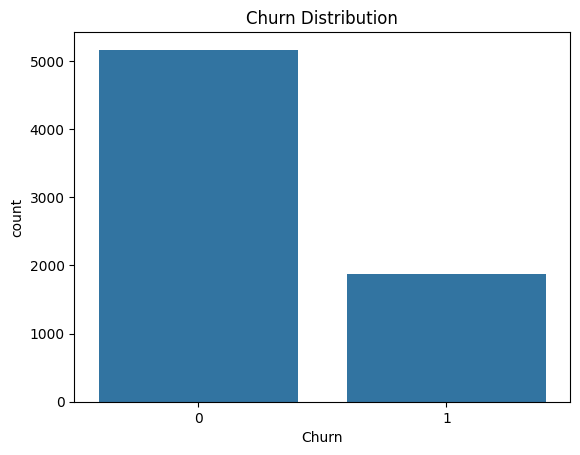

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

In [17]:
# target distribution
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()
df['Churn'].value_counts(normalize=True)

* Observation: There is class imbalance (Only ~26% people are likely to churn)

##### Numerical features vs Churn

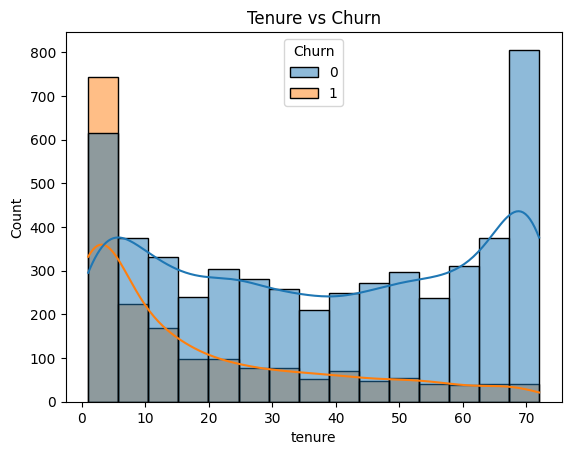

In [18]:
# numerical features vs churn
sns.histplot(data=df, x='tenure', hue='Churn', kde=True)
plt.title("Tenure vs Churn")
plt.show()

* Customers with low tenure churn more

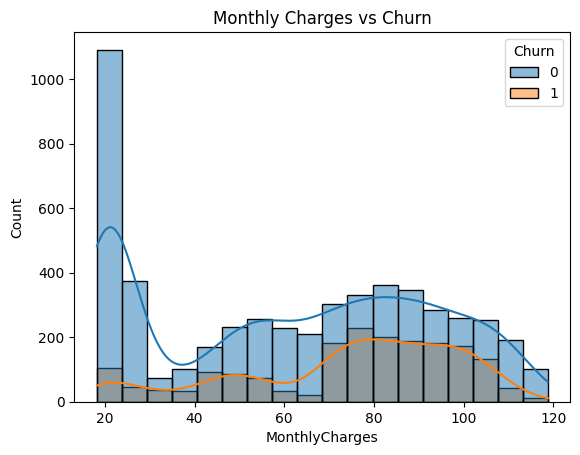

In [19]:
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True)
plt.title("Monthly Charges vs Churn")
plt.show()

* Higher monthly charges leads to higher churn tendency

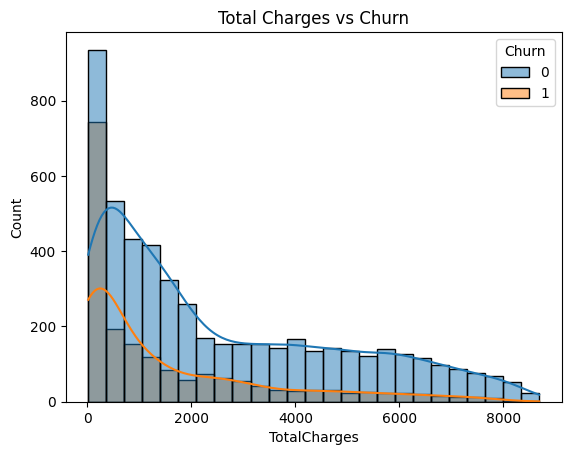

In [20]:
sns.histplot(data=df, x='TotalCharges', hue='Churn', kde=True)
plt.title("Total Charges vs Churn")
plt.show()

* Lower total charges corresponds to lower tenure. People with low total charges churn more as compared to the people with high total charges

##### Categorical Features vs Churn

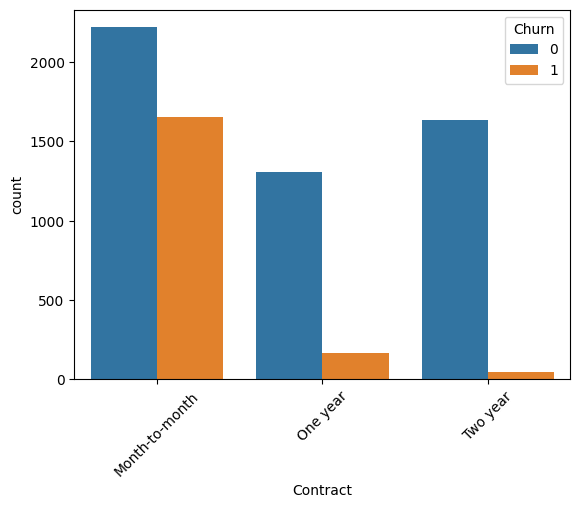

In [21]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.show()

* Month-to-month contracts churn more

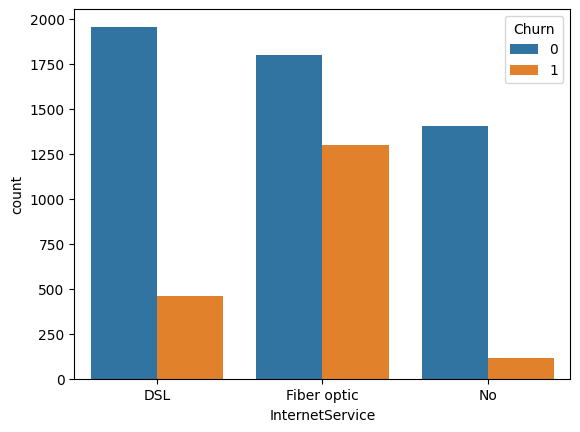

In [22]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.show()

* People with Fiber optic as intenet service churn more

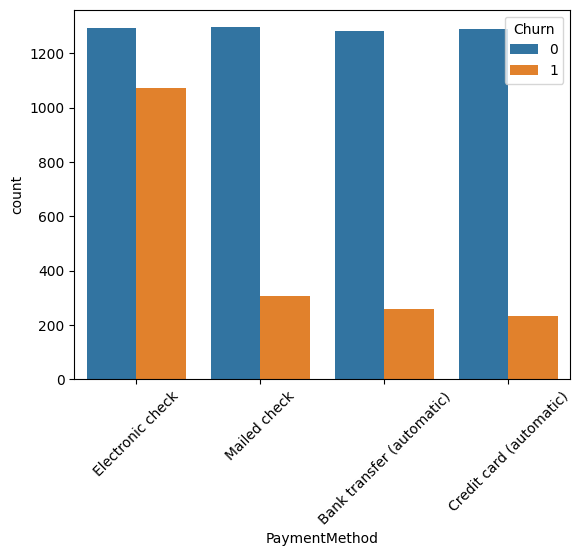

In [23]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.show()

* Observations:
    * There is data imbalance in the dataset. Only ~26% people are likely to churn
    * Customers with low tenure(hence lower total charges) churn more
    * Higher monthly charges leads to higher churn rate
    * Month-to-month contracts churn more
    * People with Fiber optic as intenet service churn more
    * People with Electronic check as payment method churn more

#### Feature Engineering

In [24]:
# separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [25]:
numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]

categorical_features = [col for col in X.columns if col not in numerical_features]

#### Train-Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

#### Encoding

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

#### Models

In [28]:
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(probability=True),
    "AdaBoost": AdaBoostClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss")
}

#### Evaluation Function

In [29]:
def evaluate_model(true, predicted, prob):
    acc = accuracy_score(true, predicted)
    precision = precision_score(true, predicted)
    recall = recall_score(true, predicted)
    f1 = f1_score(true, predicted)
    roc_auc = roc_auc_score(true, prob)

    return acc, precision, recall, f1, roc_auc

#### Train

In [30]:
model_list = []
roc_auc_list = []

for name, model in models.items():

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:,1]

    acc, precision, recall, f1, roc_auc = evaluate_model(y_test, y_pred, y_prob)

    print(f"{name}")
    print("Accuracy:", round(acc,4))
    print("Precision:", round(precision,4))
    print("Recall:", round(recall,4))
    print("F1 Score:", round(f1,4))
    print("ROC-AUC:", round(roc_auc,4))
    print("="*40)

    model_list.append(name)
    roc_auc_list.append(roc_auc)

Logistic Regression
Accuracy: 0.7257
Precision: 0.4901
Recall: 0.7968
F1 Score: 0.6069
ROC-AUC: 0.8351
Decision Tree
Accuracy: 0.7235
Precision: 0.4802
Recall: 0.4866
F1 Score: 0.4834
ROC-AUC: 0.6482
Random Forest
Accuracy: 0.7903
Precision: 0.6312
Recall: 0.508
F1 Score: 0.563
ROC-AUC: 0.8131
KNN
Accuracy: 0.7605
Precision: 0.5457
Recall: 0.5909
F1 Score: 0.5674
ROC-AUC: 0.7814
SVC
Accuracy: 0.7939
Precision: 0.6458
Recall: 0.4973
F1 Score: 0.5619
ROC-AUC: 0.7842
AdaBoost
Accuracy: 0.7903
Precision: 0.6262
Recall: 0.5241
F1 Score: 0.5706
ROC-AUC: 0.8356
XGBoost
Accuracy: 0.7669
Precision: 0.5657
Recall: 0.5294
F1 Score: 0.547
ROC-AUC: 0.8088


/Users/shaik_rehna_afroz/PROJECTS/Telecom_Customer_Churn_Prediction/venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [18:44:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [31]:
pd.DataFrame({
    "Model": model_list,
    "ROC_AUC": roc_auc_list
}).sort_values(by="ROC_AUC", ascending=False)

,Model,ROC_AUC
5,AdaBoost,0.835629
0,Logistic Regression,0.835093
2,Random Forest,0.813067
6,XGBoost,0.808840
4,SVC,0.784234
3,KNN,0.781389
1,Decision Tree,0.648198


* Observations:
    * AdaBoost has the highest ROC_AUC score(0.8356)
    * Logistic regression is very close to AdaBoost's ROC_AUC score (0.8350)
    * But in Churn prediction, Recall is very much important. Identifying the people who are likely to churn is crucial
    * Logistic Regression has highest recall(0.7968), it correctly identifies ~80% of churners
    * But AdaBoost has 0.5241 recall, which means it catches only ~52% of churners
    * Logistic regression has good balance of ROC_AUC and recall. It is simpler, more interpretable and stable for deployment
    * So considering "Logistic Regression" as the baseline model

#### Improve Logistic Regression 

In [35]:
y_prob = pipe.predict_proba(X_test)[:,1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Find threshold where recall is ~85% 
t_recallmax = 0
for t, r in zip(thresholds, recalls[:-1]):
    if r >= 0.85:
        t_recallmax = t
print(f'Threshold:{t_recallmax}')

Threshold:0.09804216772317886


In [36]:
best_f1 = 0
best_threshold = 0

for t in thresholds:
    y_pred_temp = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred_temp)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)

Best Threshold: 0.2514937
Best F1: 0.5934782608695652


* Analysis: 
    * 0.098 is the best threshold for recall >= 85%
    * But this will drop precision heavily
    * Threshold that maximizes F1 score is 0.251 and F1 score with this is 0.593
    * With the default threshold of 0.5, Recall = 0.7968, F1 = 0.6069, ROC-AUC = 0.835 which is much better than the one obatined by hyperparameter tuning
    * So the default threshold of 0.5 is optimal 